In [1]:
from dotenv import load_dotenv
import os
load_dotenv()  # Load environment variables from .env file

True

In [2]:
import os
import requests

class NvidiaChat:
    def __init__(self, model="moonshotai/kimi-k2.5", temperature=0.9):
        self.model = model
        self.temperature = temperature
        self.api_key = os.getenv("NVIDIA_API_KEY")
        self.url = "https://integrate.api.nvidia.com/v1/chat/completions"

        if not self.api_key:
            raise ValueError("Set NVIDIA_API_KEY environment variable")

    def __call__(self, prompt: str) -> str:
        response = requests.post(
            self.url,
            headers={
                "Authorization": f"Bearer {self.api_key}",
                "Content-Type": "application/json",
            },
            json={
                "model": self.model,
                "messages": [{"role": "user", "content": prompt}],
                "temperature": self.temperature,
            },
        )
        return response.json()["choices"][0]["message"]["content"]

In [ ]:
chat_llm = NvidiaChat(model="moonshotai/kimi-k2.5", temperature=0.9)

response = chat_llm("What is the capital of France?")
print(response)

In [1]:
from typing_extensions import TypedDict,Annotated
import operator

In [2]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, AnyMessage

In [3]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [4]:
def llm_call(state:GraphState)-> dict:
    """Call the LLM using conversation messages and append AI response"""
    prompt = state["messages"][-1].content
    response = chat_llm(prompt)
    return {"messages": [AIMessage(content=response)]}

In [5]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message"""
    last_mag = state["messages"][-1]
    text = last_mag.content
    token_count = len(text.split())
    summary  = f"total token number in the generated response is {token_count}"
    return {"message": [AIMessage(content=summary)]}

In [6]:
from langgraph.graph import StateGraph
builder = StateGraph(GraphState)

In [7]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [8]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [9]:
app = builder.compile()

In [10]:
app.get_graph() 

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [11]:
from IPython.display import Image, display

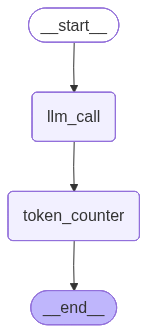

In [12]:
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of France?")]})
print(result)


NameError: name 'chat_llm' is not defined

In [14]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [15]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [16]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [17]:
wiki_tool.run({"query":"what is  genai"})

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [18]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults()
result = tavily_tool.invoke("currect date and time")
print(result)

C:\Users\vighnesh\AppData\Local\Temp\ipykernel_6860\1200486068.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


[{'title': 'Time.now: Current Time Now', 'url': 'https://time.now/', 'content': 'Shanghai  ·  Beijing  ·  Dhaka  ·  Cairo  ·  Shenzhen  ·  Guangzhou  ·  Lagos  ·  Kinshasa  ·  Istanbul  ·  Tokyo  ·  Chengdu  ·  Mumbai  ·  Moscow  ·  São Paulo  ·  Karachi  ·  Tianjin  ·  Delhi  ·  Jakarta  ·  Bangkok  ·  Wuhan  ·  Lima  ·  Seoul  ·  Dongguan  ·  Xi’an  ·  Nanjing  ·  Hangzhou  ·  Mexico City  ·  Tehran  ·  Foshan  ·  Ho Chi Minh City  ·  London  ·  New York City  ·  Bengaluru  ·  Luanda  ·  Hanoi  ·  Bogota  ·  Riyadh  ·  Hong Kong  ·  Hong Kong  ·  Chongqing  ·  Baghdad  ·  Qingdao  ·  Shenyang  ·  Rio de Janeiro  ·  Suzhou  ·  Ahmedabad  ·  Abidjan  ·  Lahore  ·  Santiago  ·  Singapore  ·  Singapore  ·  Johannesburg  ·  Dar es Salaam  ·  Saint Petersburg  ·  Alexandria  ·  Harbin  ·  Sydney  ·  Khartoum  ·  Ankara  ·  Hefei  ·  Melbourne  ·  Dalian  ·  Kano  ·  Addis [...] Sat 21:21\n ### 🇮🇳India\n\n   Sun 01:51\n ### 🇨🇦Canada\n\n   Sat 15:21\n ### 🇧🇷Brazil\n\n   Sat 17:21\n ### 🇷🇺Rus

In [19]:
from langchain_community.tools import YouTubeSearchTool

In [20]:
youtube_tool = YouTubeSearchTool()

In [21]:
youtube_tool.name

'youtube_search'

In [22]:
youtube_tool.run("campusx")

"['https://www.youtube.com/watch?v=99KPe5hIfnE&pp=ygUHY2FtcHVzeA%3D%3D', 'https://www.youtube.com/watch?v=Mf2RdpEiXjU&pp=ygUHY2FtcHVzeA%3D%3D']"

In [23]:
def multiply(a: int, b: int) -> int:
    return a * b

In [24]:
multiply(3, 4)

12

converting function into tool

In [25]:
from langchain.tools import tool

In [26]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [27]:
multiply.invoke({"a": 3, "b": 4})

12

In [28]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of a word."""
    return len(word)

In [29]:
get_word_length.invoke("word hello")

10

In [30]:
@tool
def call_gamil_api(args):
    """Calls the Gmail API with the provided arguments."""
    pass

In [31]:
import yfinance as yf

In [32]:
@tool 
def get_stock_price(ticker:str)-> str:
    """this is a tool to get stock price using yfinance library"""
    try:
        stock = yf.Ticker(ticker)
        #get last 1 day historical data
        
        data  = stock.history(period="1d")
        if data.empty:
            return f"No data found for ticker {ticker} . Please check the symbol."
        
        lastest_close = data["Close"].iloc[-1]
        
        #Detect currency
        currency = stock.info.get("currency", "")
        symbol_map ={
            "INR":"₹",
            "USD":"$",
            "EUR":"€",
            "GBP":"£",
        }
        
        symbol = symbol_map.get(currency, "")
        curreny_text = currency if currency else ""
        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{lastest_close:.2f}."
        else:
            return f"the last closing price of {ticker.upper()} was {lastest_close:.2f} {curreny_text}."
    except Exception as e:
        return f"An error occurred while fetching stock price for {ticker}: {str(e)}"

In [33]:
get_stock_price.invoke("AAPL")

'the last closing price of AAPL was $255.79.'

In [34]:
get_stock_price.invoke("TSLA")

'the last closing price of TSLA was $383.61.'

In [35]:
get_stock_price.invoke("HDFCBANK.NS")

'the last closing price of HDFCBANK.NS was ₹840.70.'

In [36]:
tools = [get_word_length, multiply, get_stock_price,wiki_tool]

In [37]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv("GROQ_API_KEY")
)

llm_with_tools = llm.bind_tools(tools)

In [38]:
result = llm_with_tools.invoke("What is the current Tesla stock price?")   

In [39]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wzg2wnvgk', 'function': {'arguments': '{"ticker":"TSLA"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 460, 'total_tokens': 477, 'completion_time': 0.023647735, 'completion_tokens_details': None, 'prompt_time': 0.032933496, 'prompt_tokens_details': None, 'queue_time': 0.046482904, 'total_time': 0.056581231}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd2f6-3c38-7081-8dbc-d6fe8e830c24-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TSLA'}, 'id': 'wzg2wnvgk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 460, 'output_tokens': 17, 'total_tokens': 477})

In [40]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TSLA'},
  'id': 'wzg2wnvgk',
  'type': 'tool_call'}]

In [41]:
results = llm_with_tools.invoke("how many words are there in the sentence 'Agentic AI is the future of artificial intelligence.'?")

In [42]:
results

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'a5xb69pvs', 'function': {'arguments': '{"word":"Agentic AI is the future of artificial intelligence."}', 'name': 'get_word_length'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 472, 'total_tokens': 496, 'completion_time': 0.032583173, 'completion_tokens_details': None, 'prompt_time': 0.035669024, 'prompt_tokens_details': None, 'queue_time': 0.046453165, 'total_time': 0.068252197}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd2f6-3d4f-7ca2-97c5-72fcc28c05c4-0', tool_calls=[{'name': 'get_word_length', 'args': {'word': 'Agentic AI is the future of artificial intelligence.'}, 'id': 'a5xb69pvs', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 472, 'output_tokens': 24, 'total_tokens': 496})

In [43]:
results.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'Agentic AI is the future of artificial intelligence.'},
  'id': 'a5xb69pvs',
  'type': 'tool_call'}]

In [44]:
result1 = llm_with_tools.invoke("can u multiply 6 and 7?")

In [45]:
result1.content

''

In [46]:
result1.tool_calls

[{'name': 'multiply',
  'args': {'a': 6, 'b': 7},
  'id': 'c3be6n08b',
  'type': 'tool_call'}]

In [48]:
result2= llm_with_tools.invoke("what is 2026 indin buget?")

In [49]:
result2

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qyddw6cek', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 462, 'total_tokens': 480, 'completion_time': 0.0452025, 'completion_tokens_details': None, 'prompt_time': 0.039640149, 'prompt_tokens_details': None, 'queue_time': 0.048491041, 'total_time': 0.084842649}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd2f7-300f-7352-af81-cb73080813a5-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'India budget 2026'}, 'id': 'qyddw6cek', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 462, 'output_tokens': 18, 'total_tokens': 480})

In [50]:
result2.content

''

In [51]:
result2.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': 'qyddw6cek',
  'type': 'tool_call'}]

ReAct

In [52]:
from langchain_core.messages import HumanMessage ,AIMessage
from langgraph.graph import MessagesState, StateGraph, END,START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


In [53]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [54]:
def function_1(state: MessagesState):
    user_question = state["messages"] 
    input_question =  [SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [55]:
tools

[StructuredTool(name='get_word_length', description='Returns the length of a word.', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001FA6C878FE0>),
 StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001FA6C8227A0>),
 StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance library', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001FA6C83C720>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\vighnesh\\project\\AgenticAI_project\\env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [56]:
function_2  = ToolNode(tools)

In [57]:
workflow  = StateGraph(MessagesState)

In [58]:
workflow.add_node("llm", function_1)

In [59]:
workflow.add_node("tools", function_2)

In [60]:
workflow.add_edge(START, "llm")

In [61]:
workflow.add_conditional_edges(
    "llm", 
    tools_condition
)

In [62]:
workflow.add_edge("tools","llm")

In [67]:
app = workflow.compile()

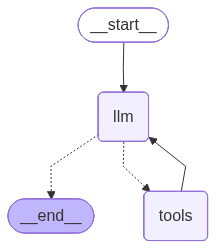

In [68]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [69]:
result4 = app.invoke({
    "messages":[HumanMessage(content="what is lastest AI news count the length")]
})

In [70]:
for m in result4["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is lastest AI news count the length
================================== Ai Message ==================================
Tool Calls:
  wikipedia (ms9g8ngbb)
 Call ID: ms9g8ngbb
  Args:
    query: latest AI news
  get_word_length (f9ygnw29d)
 Call ID: f9ygnw29d
  Args:
    word: latest AI news
================================= Tool Message =================================
Name: wikipedia

Page: Mistral AI
Summary: Mistral AI SAS (French: [mistʁal]) is a French artificial intelligence (AI) company, headquartered in Paris. Founded in 2023, it has open-weight large language models (LLMs), with both open-source and proprietary AI models. As of 2025 the company has a valuation of more than US$14 billion.



Page: Meta AI
Summary: Meta AI is a research division of Meta (formerly Facebook) that develops artificial intelligence and augmented reality technologies.



Page: AI slop
Summary
========================

In [71]:
reult =app.invoke({
    "messages":[HumanMessage(content="what is lastest AI news ")]
})

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'brave_search' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=brave_search>{"query": "latest AI news 2024"}</function>'}}

In [72]:
reult =app.invoke({
    "messages":[HumanMessage(content="give the  lastest AI news count length and muiltple it 10 ")]
})

In [74]:
for m in reult["messages"]:
    m.pretty_print()

================================ Human Message =================================

give the  lastest AI news count length and muiltple it 10 
================================== Ai Message ==================================
Tool Calls:
  wikipedia (vqkyzsy5d)
 Call ID: vqkyzsy5d
  Args:
    query: latest AI news
  get_word_length (9rsgzf8m8)
 Call ID: 9rsgzf8m8
  Args:
    word: latest AI news
  multiply (ahszx5y0n)
 Call ID: ahszx5y0n
  Args:
    a: 7
    b: 10
================================= Tool Message =================================
Name: wikipedia

Page: Mistral AI
Summary: Mistral AI SAS (French: [mistʁal]) is a French artificial intelligence (AI) company, headquartered in Paris. Founded in 2023, it has open-weight large language models (LLMs), with both open-source and proprietary AI models. As of 2025 the company has a valuation of more than US$14 billion.



Page: Meta AI
Summary: Meta AI is a research division of Meta (formerly Facebook) that develops artificial intelligen

In [76]:
result = app.invoke({
    "messages":[HumanMessage(content="How did Trump's tariff policy impact the TCS.NS?")]
})

In [77]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How did Trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fa2gtfpbh)
 Call ID: fa2gtfpbh
  Args:
    query: Trump tariff policy impact on TCS.NS
  get_stock_price (td999pgkz)
 Call ID: td999pgkz
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: wikipedia

No good Wikipedia Search Result was found
================================= Tool Message =================================
Name: get_stock_price

the last closing price of TCS.NS was ₹2527.40.
================================== Ai Message ==================================

Since the Wikipedia search did not give any useful results, I couldn't find any information on the impact of Trump's tariff policy on TCS.NS. However, according to the yfinance library, the last closing price of TCS.NS was ₹25